In [46]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from bayesian_dro.Bayesian_DRO_continuous import data_generation, xi_generation, theta_generation
from mis_dro.bayes_conjugates import normal_gamma_posterior, normal_gamma_rvs, default_prior_params, get_posterior_params, sample_posterior
from mis_dro.dataset import data_generation_outliers
from mis_dro.models import ExponentialModel
from mis_dro.npl import Npl, sample_npl

In [7]:
generator = np.random.default_rng(seed=0)
num_observations = 20

data = data_generation(num_observations, random_state=generator)  # generate new observations
lots_of_data = data_generation(10000, random_state=generator)
# data = generator.normal(10, 10, num_observations)
# data = data_generation_outliers(params["num_observations"], contamination, random_state=generator)
# data = expon.rvs(scale=20.0, size=params["num_observations"], random_state=generator)

In [8]:
num_posterior_samples = 100
p = 1  # numbers of unknown parameters

bayes_theta = theta_generation(data, num_posterior_samples, random_state=generator)

alpha_prior = 2.0
beta_prior = 2.0
mu_prior = 0.0
kappa_prior = 1.0
mu_posterior, kappa_posterior, alpha_posterior, beta_posterior = normal_gamma_posterior(data, mu_prior, kappa_prior, alpha_prior, beta_prior)
ng_theta = normal_gamma_rvs(num_posterior_samples, mu_posterior, kappa_posterior, alpha_posterior, beta_posterior, generator=generator)
ng_prior = normal_gamma_rvs(num_posterior_samples, mu_prior, kappa_prior, alpha_prior, beta_prior, generator=generator)
alpha_posterior, beta_posterior
wll_model = ExponentialModel(num_observations)
wll_npl = Npl(
    data.reshape((num_observations, 1)),
    num_posterior_samples,
    p,
    num_observations,
    wll_model,
    l=-1.0,
    loss_fn="wll",
)
wll_npl.draw_samples(random_state=generator)
wll_theta = wll_npl.sample

mmd_model = ExponentialModel(num_observations)
mmd_npl = Npl(
    data.reshape((num_observations, 1)),
    num_posterior_samples,
    p,
    num_observations,
    mmd_model,
    l=-1.0,
    loss_fn="mmd",
)
mmd_npl.draw_samples(random_state=generator)
mmd_theta = mmd_npl.sample

TypeError: Npl.__init__() missing 1 required positional argument: 'seed'

In [ ]:
num_likelihood_samples = 100
bayes_xi = np.zeros([num_posterior_samples, num_likelihood_samples])
wll_xi = np.zeros([num_posterior_samples, num_likelihood_samples])
mmd_xi = np.zeros([num_posterior_samples, num_likelihood_samples])
ng_xi = np.zeros([num_posterior_samples, num_likelihood_samples])
for i in range(num_posterior_samples):
    bayes_xi[i] = xi_generation(bayes_theta[i], num_likelihood_samples, random_state=generator)
    wll_xi[i] = xi_generation(wll_theta[i], num_likelihood_samples, random_state=generator)
    mmd_xi[i] = xi_generation(mmd_theta[i], num_likelihood_samples, random_state=generator)
    ng_xi[i] = generator.normal(ng_theta[i,0], np.sqrt(1.0 / ng_theta[i,1]), size=num_likelihood_samples)

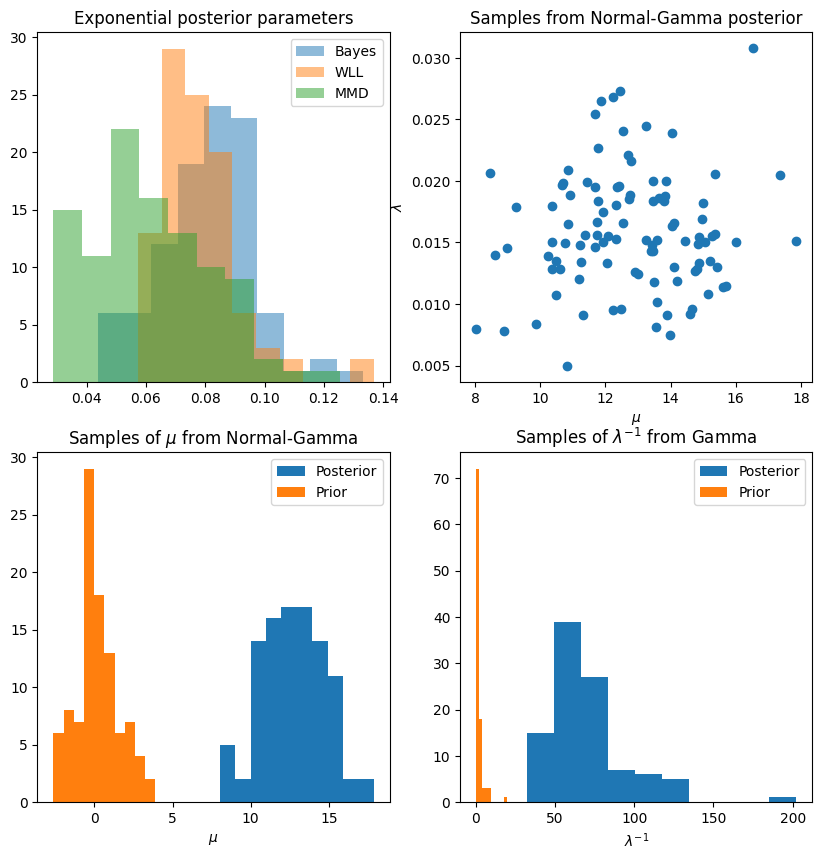

In [ ]:
# plot the posterior
n_posterior_bins = int(num_posterior_samples / 10)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
ax1.hist(bayes_theta, alpha=0.5, label="Bayes", bins=n_posterior_bins)
ax1.hist(wll_theta, alpha=0.5, label="WLL", bins=n_posterior_bins)
ax1.hist(mmd_theta, alpha=0.5, label="MMD", bins=n_posterior_bins)
ax1.legend()
ax1.set_title("Exponential posterior parameters")

# normal-gamma gets its own plot: is tricky to visualise because its a 2D posterior over both mean and precision
ax2.scatter(ng_theta[:,0], ng_theta[:,1])
ax2.set_xlabel("$\mu$")
ax2.set_ylabel("$\lambda$")
ax2.set_title("Samples from Normal-Gamma posterior")

ax3.hist(ng_theta[:,0], bins=n_posterior_bins, label="Posterior")
ax3.hist(ng_prior[:,0], bins=n_posterior_bins, label="Prior")
ax3.set_title("Samples of $\mu$ from Normal-Gamma")
ax3.set_xlabel("$\mu$")
ax3.legend()

ax4.hist(1/ng_theta[:,1], bins=n_posterior_bins, label="Posterior")
ax4.hist(1/ng_prior[:,1], bins=n_posterior_bins, label="Prior")
ax4.set_title("Samples of $\lambda^{-1}$ from Gamma")
ax4.set_xlabel("$\lambda^{-1}$")
ax4.legend()
fig.show()

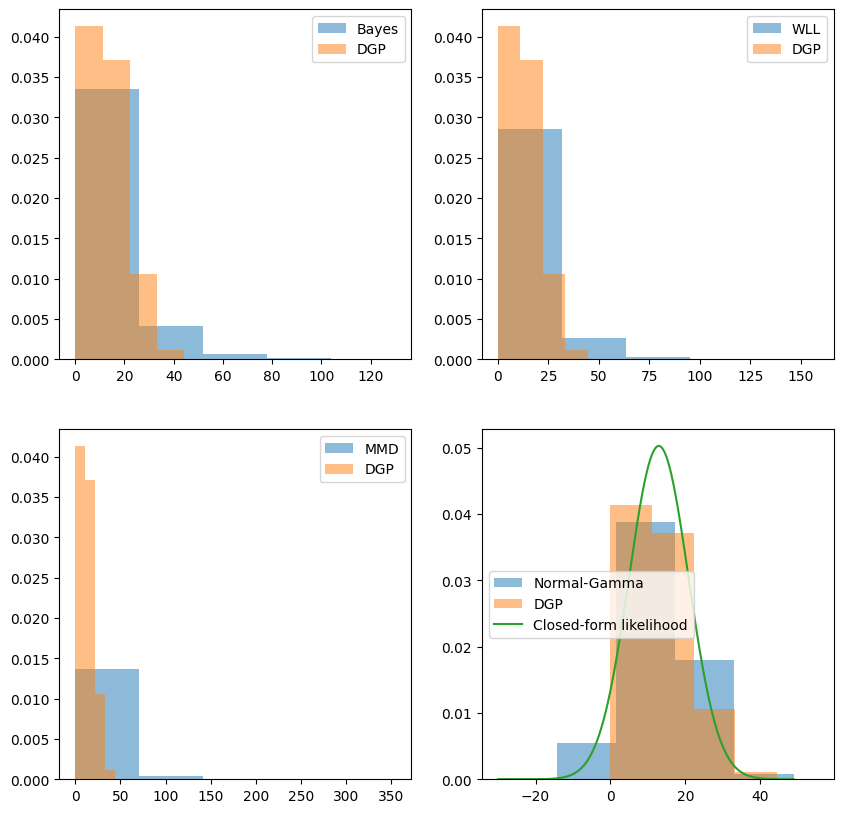

In [ ]:
# plot the likelihood
fig, ((ax1, ax2), (ax3, ax4))= plt.subplots(ncols=2, nrows=2, figsize=(10,10))
nbins = int(num_likelihood_samples / 10)
ax1.hist(bayes_xi.flatten(), alpha=0.5, label="Bayes", bins=nbins, density=True)
ax2.hist(wll_xi.flatten(), alpha=0.5, label="WLL", bins=nbins, density=True)
ax3.hist(mmd_xi.flatten(), alpha=0.5, label="MMD", bins=nbins, density=True)
ax4.hist(ng_xi.flatten(), alpha=0.5, label="Normal-Gamma", bins=nbins, density=True)

# NOTE remember to change the source of lots_of_data too!
ax1.hist(lots_of_data, alpha=0.5, label="DGP", bins=nbins, density=True)
ax2.hist(lots_of_data, alpha=0.5, label="DGP", bins=nbins, density=True)
ax3.hist(lots_of_data, alpha=0.5, label="DGP", bins=nbins, density=True)
ax4.hist(lots_of_data, alpha=0.5, label="DGP", bins=nbins, density=True)
x_values = np.arange(np.min(ng_xi.flatten()), np.max(ng_xi.flatten()), 0.001)
y_values = sp.stats.norm.pdf(x_values, mu_posterior, np.sqrt(beta_posterior / alpha_posterior))
ax4.plot(x_values, y_values, label="Closed-form likelihood")

ax1.legend()
ax2.legend()
ax3.legend()
ax4.legend()

# ax.set_xlim(-50, 50)
fig.show()

# A different contaminated exponential model

In [71]:
def contaminated_exp_small_outliers(
    num_observations: int,
    contamination: float,
    random_state = None,
):
    """A contaminated exponential data-generating process (DGP)

    Args:
        num_observations: Number of observations from DGP
        contamination: Ratio of contaminated observations (outliers)
        random_state: A numpy random generator, if provided

    Notes:
        Shuffles data to ensure anomalies are not grouped together
    """
    if not random_state:
        random_state = np.random.default_rng()
    cont_size = int(np.floor(contamination * num_observations))
    n_real = num_observations - cont_size
    data = sp.stats.expon.rvs(scale=20, size=n_real, random_state=random_state)
    outl = sp.stats.expon.rvs(scale=0.01, size=cont_size, random_state=random_state) 
    data = np.concatenate((data, outl), axis=0)
    random_state.shuffle(data)  # shuffle the data in-place
    return data

def data_generation_outliers(
    num_observations: int,
    contamination: float,
    random_state = None,
):
    """A contaminated exponential data-generating process (DGP)

    Args:
        num_observations: Number of observations from DGP
        contamination: Ratio of contaminated observations (outliers)
        random_state: A numpy random generator, if provided

    Notes:
        Shuffles data to ensure anomalies are not grouped together
    """
    if not random_state:
        random_state = np.random.default_rng()
    cont_size = int(np.floor(contamination * num_observations))
    n_real = num_observations - cont_size
    data = sp.stats.expon.rvs(scale=20, size=n_real, random_state=random_state)
    outl = sp.stats.norm.rvs(loc=1000, scale=0.5, size=cont_size, random_state=random_state) 
    data = np.concatenate((data, outl), axis=0)
    random_state.shuffle(data)  # shuffle the data in-place
    return data

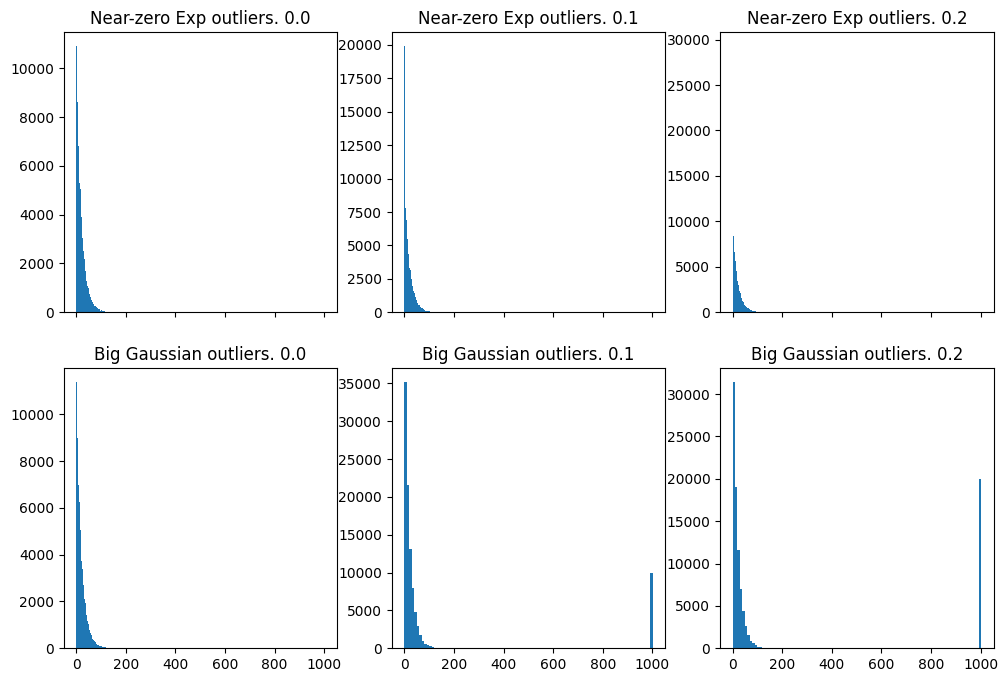

In [72]:
fig, axes = plt.subplots(ncols=3, nrows=2, figsize=(12,8), sharex=True)
num_observations = 100000
nbins = 100
for idx, contamination in enumerate([0.0, 0.1, 0.2]):   
    axes[0][idx].set_title(f"Near-zero Exp outliers. {contamination}")
    axes[0][idx].hist(contaminated_exp_small_outliers(num_observations, contamination, random_state=generator), bins=nbins)
    axes[1][idx].set_title(f"Big Gaussian outliers. {contamination}")
    axes[1][idx].hist(data_generation_outliers(num_observations, contamination, random_state=generator), bins=nbins)
fig.show()

In [73]:
likelihood = "exponential"
inference = "npl_mmd"
posterior = "gamma"
dim = 1
num_observations = 80
num_posterior_samples = 30
num_likelihood_samples = 30
exp_contam_data = []
mmd_exp_post_samples = []
bayes_exp_post_samples = []
gauss_contam_data = []
mmd_gauss_post_samples = []
bayes_gauss_post_samples = []
for idx, contamination in enumerate([0.0, 0.1, 0.2]):
    # data = contaminated_exp_small_outliers(num_observations, contamination, random_state=generator)
    # exp_contam_data.append(data)
    # theta_prior = default_prior_params(posterior, dim=dim)
    # theta_posterior = get_posterior_params(posterior, data, theta_prior)
    # bayes_exp_post_samples.append(sample_posterior(posterior, theta_posterior, num_likelihood_samples, generator=generator))
    # mmd_exp_post_samples.append(sample_npl(
    #     exp_contam_data[idx],
    #     inference,
    #     likelihood,
    #     num_posterior_samples,
    #     seed=0,
    #     lengthscale=-0.1,
    #     generator=generator,
    #     dim=1,
    # ))
    data = data_generation_outliers(num_observations, contamination, random_state=generator)
    gauss_contam_data.append(data)
    theta_prior = default_prior_params(posterior, dim=dim)
    theta_posterior = get_posterior_params(posterior, data, theta_prior)
    bayes_gauss_post_samples.append(sample_posterior(posterior, theta_posterior, num_likelihood_samples, generator=generator))
    mmd_gauss_post_samples.append(sample_npl(
        gauss_contam_data[idx],
        inference,
        likelihood,
        num_posterior_samples,
        seed=0,
        lengthscale=-0.1,
        generator=generator,
        dim=1,
    ))

    

IndexError: list index out of range

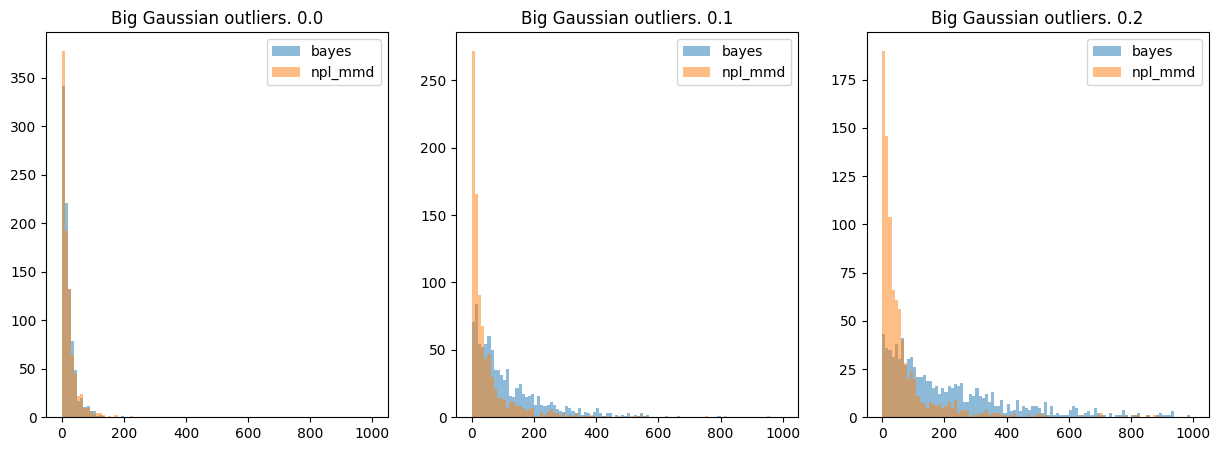

In [80]:
dgp_list = ["contaminated_exp_large_outliers"]
contamination_list = [0.0, 0.1, 0.2]
nbins = 50
ncols = len(contamination_list)
nrows = len(dgp_list)
fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(5*ncols,5*nrows))
xi = np.zeros([num_posterior_samples, num_likelihood_samples])
for row, dgp in enumerate(dgp_list):
    for idx, contamination in enumerate(contamination_list):
        for inference in ["bayes", "npl_mmd"]:
            xi = np.zeros([num_posterior_samples, num_likelihood_samples])
            # if inference == "bayes" and dgp == "contaminated_exp_small_outliers":
            #     theta = bayes_exp_post_samples[idx]
            # elif inference == "npl_mmd" and dgp == "contaminated_exp_small_outliers":
            #     theta = mmd_exp_post_samples[idx]
            if inference == "bayes" and dgp == "contaminated_exp_large_outliers":
                theta = bayes_gauss_post_samples[idx]
            elif inference == "npl_mmd" and dgp == "contaminated_exp_large_outliers":
                theta = mmd_gauss_post_samples[idx]
            else:
                raise ValueError()
            for i in range(num_posterior_samples):
                xi[i] = xi_generation(theta[i], num_likelihood_samples, random_state=generator)
            axes[idx].hist(xi.flatten(), label=inference, alpha=0.5, bins=np.arange(0, 1010, 10))
            axes[idx].legend()
        if dgp == "contaminated_exp_small_outliers":
            axes[idx].set_title(f"Near-zero Exp outliers. {contamination}")
        elif dgp == "contaminated_exp_large_outliers":
            axes[idx].set_title(f"Big Gaussian outliers. {contamination}")
        
np.mean(exp_contam_data[0])

(array([2.9258e+04, 8.0900e+03, 7.1650e+03, 6.4590e+03, 5.5390e+03,
        4.9700e+03, 4.4430e+03, 3.9490e+03, 3.4650e+03, 3.1000e+03,
        2.7180e+03, 2.3180e+03, 2.0820e+03, 1.9170e+03, 1.6470e+03,
        1.4000e+03, 1.3350e+03, 1.1330e+03, 9.7400e+02, 8.8900e+02,
        7.6800e+02, 7.0000e+02, 6.6600e+02, 5.8000e+02, 5.0500e+02,
        4.3900e+02, 4.2000e+02, 3.4100e+02, 3.3400e+02, 2.8200e+02,
        2.3800e+02, 2.1000e+02, 1.8900e+02, 1.8300e+02, 1.4800e+02,
        1.3900e+02, 1.1400e+02, 8.7000e+01, 8.9000e+01, 7.5000e+01,
        6.7000e+01, 5.4000e+01, 6.0000e+01, 5.2000e+01, 3.8000e+01,
        5.0000e+01, 4.2000e+01, 2.9000e+01, 2.6000e+01, 3.5000e+01,
        2.1000e+01, 1.8000e+01, 1.2000e+01, 2.1000e+01, 1.9000e+01,
        1.1000e+01, 1.1000e+01, 1.2000e+01, 8.0000e+00, 7.0000e+00,
        8.0000e+00, 4.0000e+00, 5.0000e+00, 4.0000e+00, 4.0000e+00,
        3.0000e+00, 2.0000e+00, 0.0000e+00, 0.0000e+00, 2.0000e+00,
        1.0000e+00, 3.0000e+00, 0.0000e+00, 2.00

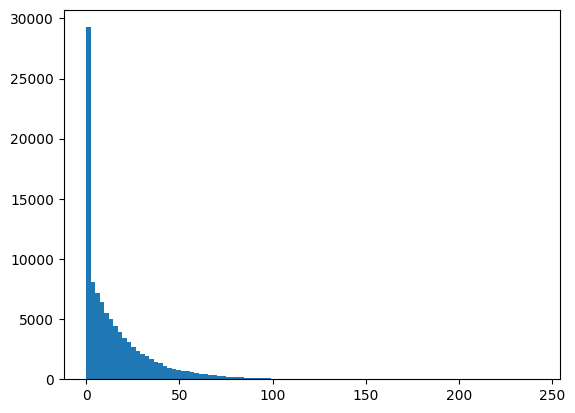

In [57]:
plt.hist(contaminated_exp_small_outliers(100000, 0.2, random_state=generator), bins=100)